## **Exploratory Data Analysis For Phishing Dataset**

### Dataset
> This dataset, sourced from CyberProtect, includes multiple technical and behavioural attributes of websites.
> 
> Each website is assigned a label:
> - 0 for phishing
> - 1 for legitimate.
>
>The labels allow comparison between suspicious and safe sites so patterns can be observed across different features for analysis and future model training.
> 
### Objective of EDA
> Assess data quality, study feature distributions, and uncover meaningful relationships between attributes and the target (label: 0 = phishing, 1 = legitimate). Insights from these steps will inform machine learning model selection and guide preprocessing decisions for phishing website classification.
>
> 
### EDA Process Summary
> - Load the data to understand its structure and get overview of dataset
> - Examine target variables and class balance
> - Check for missing values and duplicated rows
> - Investigate data quality issues (wrong types, anomalies, negative counts)
> - Explore distributions and outliers in numerical features
> - Explore categorical features and their relationship to website legitimacy
> - Summarise key findings and implications for modelling


In [ ]:
!pip install pandas matplotlib numpy

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

## **Data loading**

In [2]:
database = 'data/phishing.db'

conn = sqlite3.connect(database)

df = pd.read_sql("SELECT * FROM phishing_data;", conn)

## **Attributes Reference**

In [3]:
pd.set_option("display.max_colwidth", None)  # shows full text in cells
attributes = {
    "Attribute": [
        "LineOfCode",
        "LargestLineLength",
        "NoOfURLRedirect",
        "NoOfSelfRedirect",
        "NoOfPopup",
        "NoOfiFrame",
        "NoOfImage",
        "NoOfSelfRef",
        "NoOfExternalRef",
        "Robots",
        "IsResponsive",
        "Industry",
        "DomainAgeMonths",
        "HostingProvider",
        "label"
    ],
    "Description": [
        "Number of lines of code",
        "Longest line of code",
        "Number of URL redirects from the website",
        "Number of self redirects from the website",
        "Number of Pop ups from the website",
        "Number of iFrames from the website",
        "Number of Images found in the website",
        "Number of clickable links within the same domain",
        "Number of clickable links to external websites",
        "Does the website have a robot.txt (0 = No, 1 = Yes)",
        "Indicates if the website is responsive across devices (0 = No, 1 = Yes)",
        "The industry that the website belongs to",
        "Number of months since the domain was created",
        "Hosting provider of the website",
        "0 = phishing website, 1 = legitimate website"
    ]
}

attr_df = pd.DataFrame(attributes)

attr_df


,Attribute,Description
0,LineOfCode,Number of lines of code
1,LargestLineLength,Longest line of code
2,NoOfURLRedirect,Number of URL redirects from the website
3,NoOfSelfRedirect,Number of self redirects from the website
4,NoOfPopup,Number of Pop ups from the website
5,NoOfiFrame,Number of iFrames from the website
6,NoOfImage,Number of Images found in the website
7,NoOfSelfRef,Number of clickable links within the same domain
8,NoOfExternalRef,Number of clickable links to external websites
9,Robots,"Does the website have a robot.txt (0 = No, 1 = Yes)"


## **Dataset Overview**
> Basic checking on number of rows, columns, and data types.
> - The dataset has 10500 rows and 16 columns.
> - Most datatypes are numeric, and categorical features such as `Industry` and `HostingProvider` appear as object.
> - The mix of numeric and categorical features suggests we must carefully design preprocessing for different models.

In [4]:
df.head()

,Unnamed: 0,LineOfCode,LargestLineLength,NoOfURLRedirect,NoOfSelfRedirect,NoOfPopup,NoOfiFrame,NoOfImage,NoOfSelfRef,NoOfExternalRef,Robots,IsResponsive,Industry,HostingProvider,DomainAgeMonths,label
0,0,NaN,9965,0,0,2,1,48,172,170,1,1,Fashion,DreamHost,98,0
1,1,769.0,9507,0,0,0,4,25,55,78,1,1,Fashion,AWS,31,1
2,2,720.0,2550,0,0,0,2,-31,94,13,0,1,Education,Google Cloud,26,1
3,3,198.0,869,0,0,0,0,0,0,2,0,0,Unknown,DreamHost,2,1
4,4,972.0,2807,0,0,0,2,6,83,51,0,1,Education,GoDaddy,43,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         10500 non-null  int64  
 1   LineOfCode         8145 non-null   float64
 2   LargestLineLength  10500 non-null  int64  
 3   NoOfURLRedirect    10500 non-null  int64  
 4   NoOfSelfRedirect   10500 non-null  int64  
 5   NoOfPopup          10500 non-null  int64  
 6   NoOfiFrame         10500 non-null  int64  
 7   NoOfImage          10500 non-null  int64  
 8   NoOfSelfRef        10500 non-null  int64  
 9   NoOfExternalRef    10500 non-null  int64  
 10  Robots             10500 non-null  int64  
 11  IsResponsive       10500 non-null  int64  
 12  Industry           10500 non-null  object 
 13  HostingProvider    10500 non-null  object 
 14  DomainAgeMonths    10500 non-null  int64  
 15  label              10500 non-null  int64  
dtypes: float64(1), int64(1

## **Target Analysis**
>The dataset contains both phishing and legitimate website samples, as indicated in the `label` column.
>
>Only two discrete classes are present (0 = False, 1 = True), so the target is treated as a binary categorical variable.
>
>The class distribution is **44.96% (Class 0)** and **55.04% (Class 1)**, with a ratio of 1 : 1.22, reflecting a slight class skew but still considered sufficiently balanced for machine learning purposes.
>
>No imbalance-specific treatment is required at this stage. However, model metrics should be monitored after training to ensure neither class is
>disadvantaged in predictions.

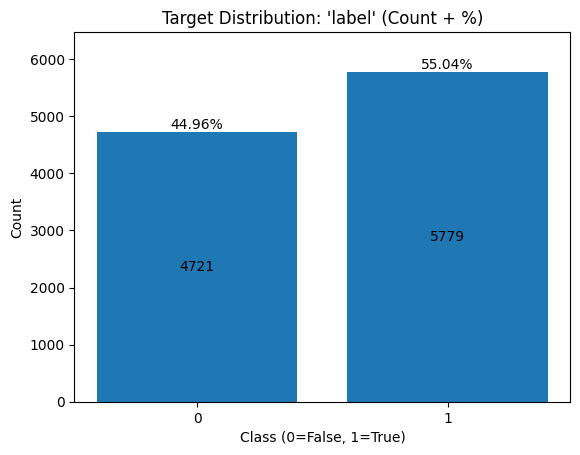

Class Ratio (0:1) ≈ 1:1.22


In [6]:
counts = df['label'].value_counts().sort_index()
percent = df['label'].value_counts(normalize=True).sort_index() * 100

# Plot bars
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)

# Add count labels inside bars
for i, v in enumerate(counts.values):
    ax.text(i, v/2, str(v), ha='center', va='center')

# Add percentage labels above bars
for i, p in enumerate(percent.values):
    ax.text(i, counts.values[i] + max(counts.values)*0.01, f"{p:.2f}%", ha='center')

# Force x-axis to show only 0 and 1 ticks
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])

# Formatting
ax.set_title("Target Distribution: 'label' (Count + %)")
ax.set_xlabel("Class (0=False, 1=True)")
ax.set_ylabel("Count")
plt.ylim(0, max(counts.values) * 1.12)

plt.show()

minority = counts.min()
majority = counts.max()
ratio = majority / minority
print(f"Class Ratio (0:1) ≈ 1:{ratio:.2f}")

## **Check for Missing values and Duplicated rows**
> There is no duplicated rows in all the columns. However, it was observed that all missing `null` entries in the `LineOfCode` feature correspond exclusively to Class 0 (phishing websites) in the target `label` column.
> This indicates that the missing data is target-linked, not random.
> 
> The missing values in LineOfCode may represent a potential predictive pattern rather than corrupted data, so no rows were removed to avoid loss of target class signals. 
>
> - **The `null` values will be imputed using the median during pre-processing to ensure ML compatibility**
> - **Add missing flag (LineOfCode_missing) to preserve potential signal**

In [7]:
print("Null values per column:")
print(df.isnull().sum())
print("-------------------------")
print("Duplicate rows:", df.duplicated().sum())

Null values per column:
Unnamed: 0              0
LineOfCode           2355
LargestLineLength       0
NoOfURLRedirect         0
NoOfSelfRedirect        0
NoOfPopup               0
NoOfiFrame              0
NoOfImage               0
NoOfSelfRef             0
NoOfExternalRef         0
Robots                  0
IsResponsive            0
Industry                0
HostingProvider         0
DomainAgeMonths         0
label                   0
dtype: int64
-------------------------
Duplicate rows: 0


In [8]:
nulls_by_label = df[df["LineOfCode"].isnull()]["label"].value_counts().sort_index()
print("\nLineOfCode nulls grouped by label:")
print(nulls_by_label.to_string())


LineOfCode nulls grouped by label:
label
0    2355


## `LineOfCode` Stored as Float but represents Integers
> Although pandas shows the column dtype as `float`, inspection of values confirms that:
>- All non-null values are whole numbers
>- No actual decimal values exist in the dataset
>- The float type is likely a storage or import artifact, not true numeric contamination
>
>Evidence is shown below using `.describe()` and filtering non-whole numbers, which returned only null values.
This column can be safely converted to integer in ML pipeline.

In [9]:
df['LineOfCode'].describe()

count      8145.000000
mean       1376.952363
std        5751.557001
min           2.000000
25%          88.000000
50%         620.000000
75%        1452.000000
max      418650.000000
Name: LineOfCode, dtype: float64

In [10]:
df[df['LineOfCode'] % 1 != 0][['LineOfCode']].head(10)

,LineOfCode
0,NaN
14,NaN
15,NaN
20,NaN
22,NaN
24,NaN
25,NaN
26,NaN
27,NaN
29,NaN


## **Check for Anomaly & Outliers**
>To detect unusual values and anomalies in both numeric and categorical data, including extremely large values, negative values (where they should not exist), and statistical outliers.
>
>**For Numeric Data:**
>Outliers are detected using the 1.5 × IQR (Interquartile Range) rule. Additionally, the unique value count is displayed to determine whether a
>feature is binary (2 unique values) or continuous/non-binary, which helps guide further data processing decisions.
>
>**For Categorical Data:**
>The unique value count is checked to understand the number of distinct categories and identify if the feature is binary-class.
>Category frequency distribution is inspected to detect rare labels, which may signal typos, inconsistent naming, or data entry errors.
>Formatting consistency is also evaluated to flag dirty data, such as leading/trailing spaces and inconsistent capitalization, which can represent >categorical anomalies that require cleaning.

### **Findings in Numerical Data**

In [11]:
# 1.5 * IQR calculation to detect outlier

def iqr_cal(df, col):
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    return mask, lower, upper, iqr

In [12]:
print("--------- Numerical Data ---------")

def anomaly_numeric(df):
    num_cols = df.select_dtypes(include="number").columns

    for col in num_cols:
        s = df[col].dropna()

        print(f"\n===== {col} =====")

        # check binary possibility
        n_unique = s.nunique()
        print("Unique values:", n_unique)

        if n_unique == 2:
            print("**This looks binary**")
        else:
            print("Not binary")

        # Negative value check 
        neg_mask = df[col] < 0
        n_negatives = neg_mask.sum()
        print("Negative values found:", n_negatives)

        if n_negatives > 0:
            print("\nExamples of negative values:")
            print(df.loc[neg_mask, col].head(5).to_string(index=False))
            print("\n")

        mask, lower, upper, IQR = iqr_cal(df, col)

        print(f"IQR value                 : {IQR}")
        print(f"Lower bound (Q1 - 1.5*IQR): {lower}")
        print(f"Upper bound (Q3 + 1.5*IQR): {upper}")
        print("Outliers found            :", mask.sum())

anomaly_numeric(df)

--------- Numerical Data ---------

===== Unnamed: 0 =====
Unique values: 10500
Not binary
Negative values found: 0
IQR value                 : 5249.5
Lower bound (Q1 - 1.5*IQR): -5249.5
Upper bound (Q3 + 1.5*IQR): 15748.5
Outliers found            : 0

===== LineOfCode =====
Unique values: 2875
Not binary
Negative values found: 0
IQR value                 : 1364.0
Lower bound (Q1 - 1.5*IQR): -1958.0
Upper bound (Q3 + 1.5*IQR): 3498.0
Outliers found            : 680

===== LargestLineLength =====
Unique values: 4027
Not binary
Negative values found: 0
IQR value                 : 7866.25
Lower bound (Q1 - 1.5*IQR): -11618.625
Upper bound (Q3 + 1.5*IQR): 19846.375
Outliers found            : 757

===== NoOfURLRedirect =====
Unique values: 2
**This looks binary**
Negative values found: 0
IQR value                 : 0.0
Lower bound (Q1 - 1.5*IQR): 0.0
Upper bound (Q3 + 1.5*IQR): 0.0
Outliers found            : 1436

===== NoOfSelfRedirect =====
Unique values: 2
**This looks binary**
Negati

>Based on the result, it is stated that `NoOfURLRedirect`, `NoOfSelfRedirect`,`Robotss`,`IsResponsive` and `label` is binary data.
>
> While all these columns are technically binary with 2 unique values, some are logical flags representing a state (True/False), and others are
> numerical measurements that happen to have only 0 or 1 values, but actually describe an instance count, not a boolean condition.
> 
> **Binary-as-Count:**
> - `NoOfURLRedirect`: Number of URL redirect from the website
> - `NoOfSelfRedirect`: Number of Self redirect from the website
> 
> **Binary-as-Flag: (True = 1 / False = 0)**
> 
> - `Robots`: Does the website have a robot.txt
> - `IsResponsive`: Is the website can be appropriately adapted across devices
> - `Label`: 0 means phishing website and 1 means legitimate website

>These features were retained for analysis because they may provide meaningful signals for distinguishing between phishing and legitimate websites.
>
>The observed skew toward a specific class, 0 for `Robots` and 1 for `IsResponsive`, may offer useful insights, as consistent behavioral patterns in
>these features could help indicate whether a website is more likely to be phishing or legitimate.


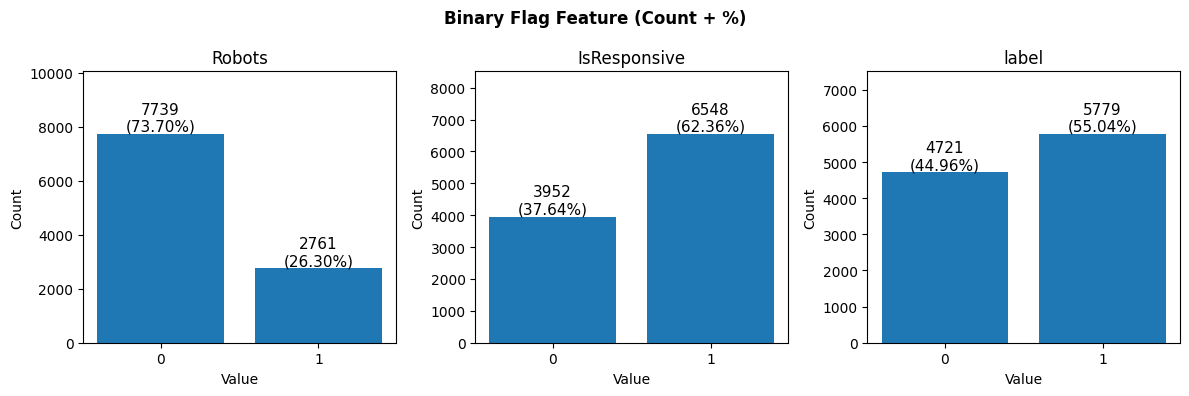

In [13]:
binary_flag_cols = ["Robots", "IsResponsive", "label"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, binary_flag_cols):
    counts = df[col].value_counts().sort_index()
    total = counts.sum()
    pct = (counts / total) * 100

    bars = ax.bar(counts.index.astype(str), counts)
    ax.set_ylim(0, counts.max() * 1.3)

    # add labels
    for bar, c, p in zip(bars, counts, pct):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{c}\n({p:.2f}%)",
            ha='center', va='bottom', fontsize=11
        )

    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

fig.suptitle("Binary Flag Feature (Count + %)", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

#### **Outliers**
> Outliers with extreme values were detected in `LineOfCode`, `LargestLineLength`,
> `NoOfPopup`, `NoOfiFrame`, `NoOfImage`, `NoOfSelfRef` and `NoOfExternalRef` using IQR analysis
> and Box Plot to understand their spread on both ends of the distribution.
>
> To visualize magnitude without suppressing sign, a symlog scaling was applied to boxplot views.
> This preserves negative values, zero, and extreme positives in one frame, while compressing scale-dominant outliers for interpretability.


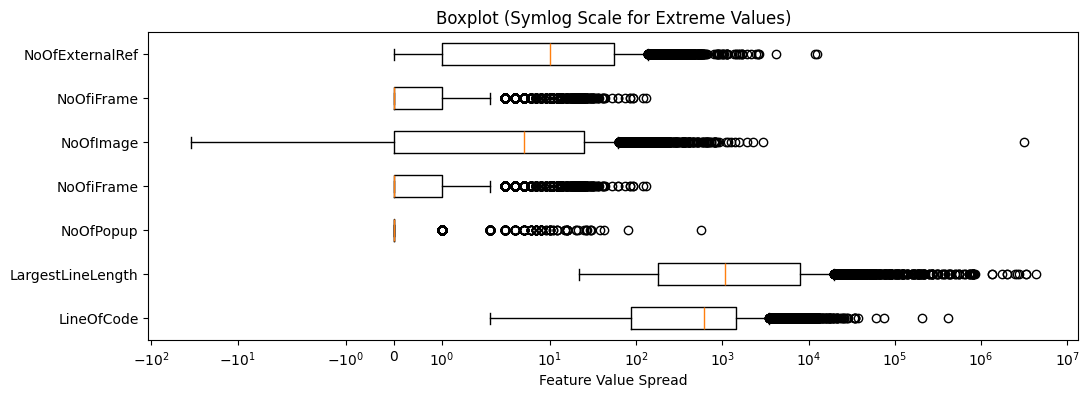

In [14]:
cols = [ 'LineOfCode', 'LargestLineLength', 'NoOfPopup', 'NoOfiFrame',
         'NoOfImage', 'NoOfiFrame', 'NoOfExternalRef' ]

data = [df[col].dropna() for col in cols]

plt.figure(figsize=(12, 4))
plt.boxplot(data, tick_labels=cols, vert=False)
plt.xscale("symlog")
plt.title("Boxplot (Symlog Scale for Extreme Values)")
plt.xlabel("Feature Value Spread")
plt.show()

> `NOofImage`, a discrete count feature intended to represent the number of images on a webpage,
> also contains unexpected negative values. 
> Label comparison shows that:
>
>- 70 negative values belong to label = 0 (phishing)
>
>- 307 negative values belong to label = 1 (legit)
>
>  
>This suggests that the negative values are not a characteristic of phishing or illegitimacy, but a systemic data collection or parsing error, especially affecting legitimate website rows.
>
> These negative entries will be addressed such converting invalid negatives to a defined fallback or clip it to 0

In [15]:
# Filter negative values in NoOfImage
neg_rows = df[df["NoOfImage"] < 0]

# Count total negatives
total_neg = neg_rows.shape[0]
print("Total negative NoOfImage values :", total_neg)

# Compare with website legitimacy label
neg_label_counts = neg_rows["label"].value_counts().sort_index()
print("\nNegative NoOfImage count by label:")
print(neg_label_counts.to_string())

# show a few example rows to inspect them
print("\nExample negative rows with labels:")
print(neg_rows[["NoOfImage", "label"]].head())


Total negative NoOfImage values : 377

Negative NoOfImage count by label:
label
0     70
1    307

Example negative rows with labels:
    NoOfImage  label
2         -31      1
34        -31      1
44        -34      1
58        -34      1
67        -31      1


### Outlier counts aginst Target `label`

> Breakdown of outlier counts against the label column (1 = legitimate, 0 = phishing) reveals that extreme values exist in both classes, indicating
> that large magnitudes may be natural but rare cases (unusually large or complex websites), rather than systemic corruption.
> 
> This analysis supports retaining the features for modeling, as the model should learn normal vs abnormal behavior for each class. 
>
> The rows will be retained for modeling, but values may undergo imputation for missing values, percentile-based clipping, or
> RobustScaler transformation to reduce outlier distortion during model training, depending on the chosen model pipeline.

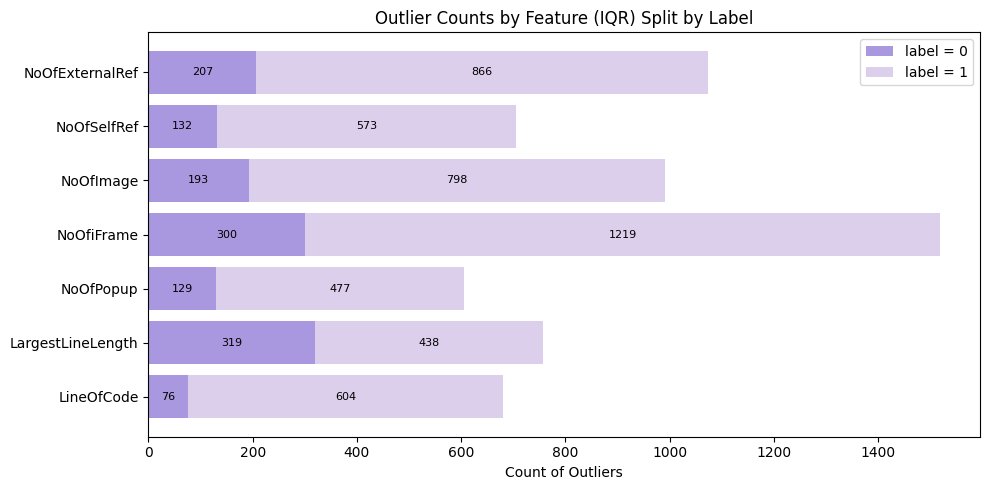

In [16]:
cols = ['LineOfCode', 'LargestLineLength', 'NoOfPopup', 'NoOfiFrame',
        'NoOfImage', 'NoOfSelfRef', 'NoOfExternalRef']

outlier_split = {}

for col in cols:
    mask, lower, upper, IQR = iqr_cal(df, col)

    outlier_0 = (mask & (df['label'] == 0)).sum()
    outlier_1 = (mask & (df['label'] == 1)).sum()

    outlier_split[col] = (outlier_0, outlier_1)

labels = list(outlier_split.keys())
out_0 = [v[0] for v in outlier_split.values()]
out_1 = [v[1] for v in outlier_split.values()]

plt.figure(figsize=(10, 5))
b0 = plt.barh(labels, out_0, label="label = 0", color="#A997DF")
b1 = plt.barh(labels, out_1, left=out_0, label="label = 1", color="#DCCFEC")

plt.title("Outlier Counts by Feature (IQR) Split by Label")
plt.xlabel("Count of Outliers")
plt.legend()

# annotate counts
for bar, count in zip(b0, out_0):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_y() + bar.get_height()/2,
             str(count),
             ha="center", va="center", fontsize=8)

for bar, count in zip(b1, out_1):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_y() + bar.get_height()/2,
             str(count),
             ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


### **Findings in Categorical Data**

In [17]:
print("--------- Catagorical Data ---------")

def anomaly_categorical(df, rare_thresh=5):
    cat_cols = df.select_dtypes(include="object").columns

    for col in cat_cols:
        print(f"\n===== {col} =====")
        print("Unique categories:", df[col].nunique())

        freq = df[col].value_counts(dropna=False)
        print("\nCategory frequencies:")
        print(freq.to_string())  # cleaner print

        # Rare check
        rare = freq[freq < rare_thresh]
        if not rare.empty:
            print("\n Rare categories:")
            print(rare.to_string())

        # Extra space check
        space_mask = df[col].dropna().apply(lambda x: x != x.strip())

        if space_mask.sum() > 0:
            print(f"\n Values with extra spaces detected: {space_mask.sum()}")
            print("\nExamples:")
            
            # print actual problematic values (no header/footer)
            print(df.loc[space_mask, col].head(5).to_string(index=False))

anomaly_categorical(df)

--------- Catagorical Data ---------

===== Industry =====
Unique categories: 11

Category frequencies:
Industry
eCommerce        2521
Non-profit       1580
Education        1486
Unknown          1446
Fashion           839
Manufacturing     658
Government        543
eCommerce         444
Healthcare        423
Food              296
Banking           264

 Values with extra spaces detected: 444

Examples:
eCommerce 
eCommerce 
eCommerce 
eCommerce 
eCommerce 

===== HostingProvider =====
Unique categories: 13

Category frequencies:
HostingProvider
Unknown Provider    1177
GoDaddy              940
Bluehost             908
HostGator            885
Freehostia           805
000webhost           776
InfinityFree         768
Google Cloud         763
AWS                  754
Azure                746
Hostinger            701
Namecheap            666
DreamHost            611


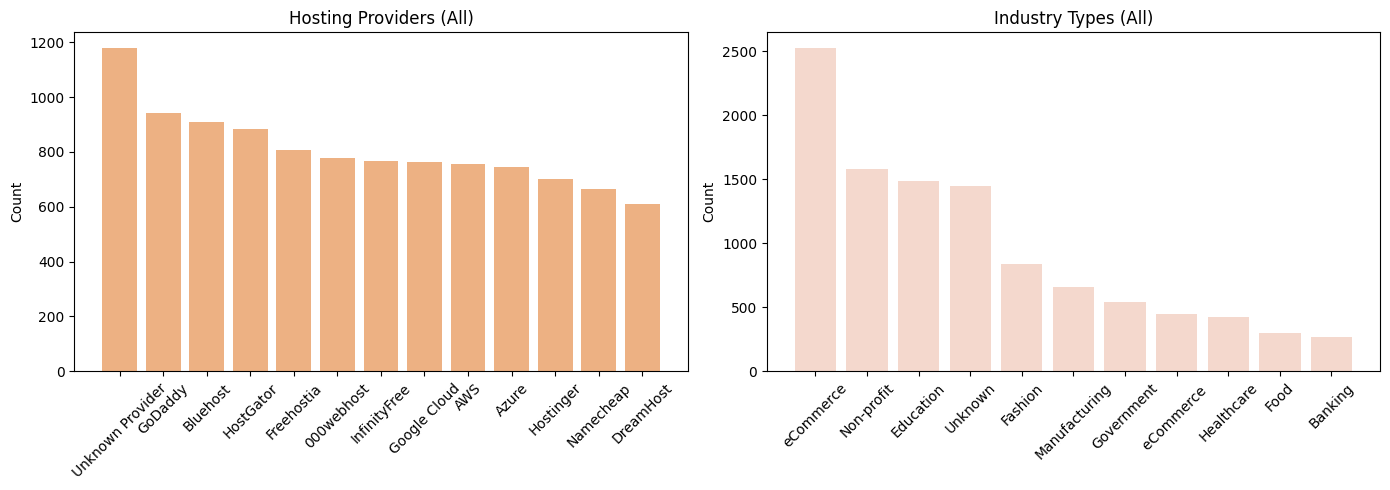

In [18]:
# Category counts for both columns
host_counts = df['HostingProvider'].value_counts().sort_values(ascending=False)
industry_counts = df['Industry'].value_counts().sort_values(ascending=False)

# Create 2 bar charts side by side 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Industry chart
axes[1].bar(industry_counts.index, industry_counts.values, color="#F4D8CD")
axes[1].set_title("Industry Types (All)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# HostingProvider chart
axes[0].bar(host_counts.index, host_counts.values, color="#EDB183")
axes[0].set_title("Hosting Providers (All)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()


> Category inconsistencies caused by trailing whitespace ("ecommerce" vs "ecommerce ") were identified in the `Industry` column.
>
>  String normalization using `.strip()` was applied to remove leading and trailing spaces, ensuring equivalent industries are merged into a single category for accurate analysis and ML compatibility.

In [19]:
df['Industry'] = df['Industry'].str.strip()
print(df['Industry'].value_counts())

Industry
eCommerce        2965
Non-profit       1580
Education        1486
Unknown          1446
Fashion           839
Manufacturing     658
Government        543
Healthcare        423
Food              296
Banking           264
Name: count, dtype: int64


>The HostingProvider and Industry columns were analyzed to understand how category representation relates to website legitimacy (label: 0 = phishing, 1 = legitimate).
>
> Certain hosting providers show a higher concentration of phishing-related domains (label = 0), while others host a larger share of legitimate websites (label = 1). This suggests that hosting provider may carry predictive value rather than appearing as random noise.
>
> `Unknown providers`, `000webhost`, `Freehostia`, `infinityFree` providers and `Ecommerce` industry shows a significantly high amount of phishing site, indicating itself maybe a legitimacy risk indicator.
>
> No rows were dropped as the goal is to evaluate real-world legitimacy patterns across all category.

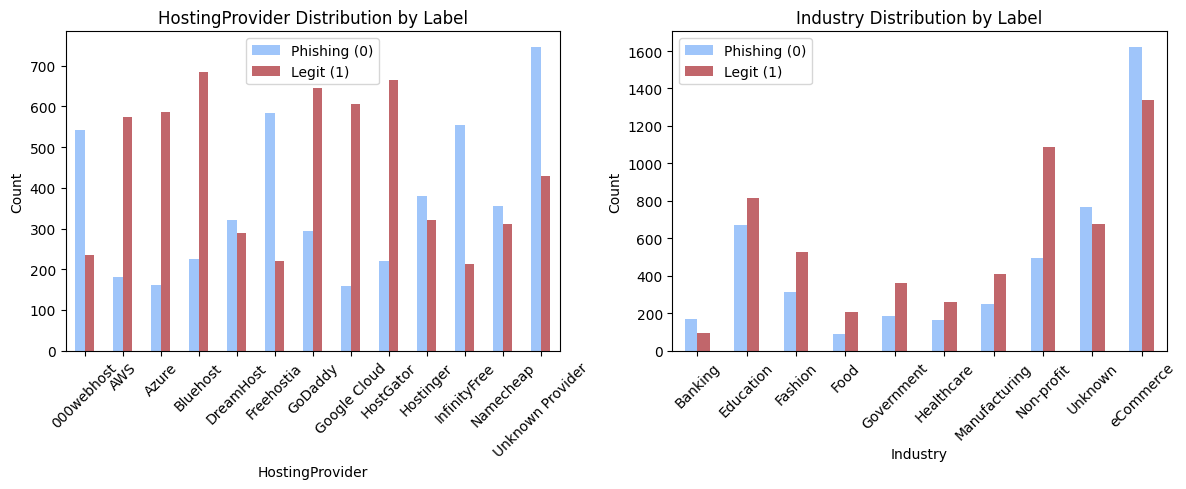

In [20]:
host_label_counts = df.groupby('HostingProvider')['label'].value_counts().unstack(fill_value=0)
industry_label_counts = df.groupby('Industry')['label'].value_counts().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# HostingProvider Chart
host_label_counts.plot(
    kind='bar',
    ax=axes[0],
    color=['#9FC5FA', '#C1666B']  # 0 first (blue), 1 second (pink)
)
axes[0].set_title("HostingProvider Distribution by Label")
axes[0].set_ylabel("Count")
axes[0].legend(["Phishing (0)", "Legit (1)"])
axes[0].tick_params(axis='x', rotation=45)

# Industry Chart
industry_label_counts.plot(
    kind='bar',
    ax=axes[1],
    color=['#9FC5FA', '#C1666B']
)
axes[1].set_title("Industry Distribution by Label")
axes[1].set_ylabel("Count")
axes[1].legend(["Phishing (0)", "Legit (1)"])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## **Correlations**

In [21]:
cols = [
    "LineOfCode",
    "LargestLineLength",
    "NoOfURLRedirect",
    "NoOfSelfRedirect",
    "NoOfPopup",
    "NoOfiFrame",
    "NoOfImage",
    "NoOfSelfRef",
    "NoOfExternalRef",
    "Robots",
    "IsResponsive",
    "DomainAgeMonths",
    "label"
]

corr = df[cols].corr()
corr

,LineOfCode,LargestLineLength,NoOfURLRedirect,NoOfSelfRedirect,NoOfPopup,NoOfiFrame,NoOfImage,NoOfSelfRef,NoOfExternalRef,Robots,IsResponsive,DomainAgeMonths,label
LineOfCode,1.000000,0.011600,0.024689,0.001366,0.066929,0.160649,0.043958,0.467163,0.172389,0.039224,0.098927,0.101115,0.092799
LargestLineLength,0.011600,1.000000,0.006556,-0.012045,-0.001765,0.008973,-0.000861,-0.002532,-0.004458,0.014055,0.009925,-0.030088,-0.022636
NoOfURLRedirect,0.024689,0.006556,1.000000,0.502573,0.003174,0.079584,-0.003790,0.000888,-0.009831,-0.040673,-0.048354,-0.034320,-0.024153
NoOfSelfRedirect,0.001366,-0.012045,0.502573,1.000000,0.003221,0.012830,-0.001912,-0.002464,-0.004226,-0.035128,-0.101121,-0.028012,-0.037181
NoOfPopup,0.066929,-0.001765,0.003174,0.003221,1.000000,0.033351,-0.000029,0.049305,0.100574,0.001701,0.008662,0.019329,0.023348
NoOfiFrame,0.160649,0.008973,0.079584,0.012830,0.033351,1.000000,0.003237,0.096032,0.087160,0.045914,0.159951,0.148332,0.149633
NoOfImage,0.043958,-0.000861,-0.003790,-0.001912,-0.000029,0.003237,1.000000,0.000247,-0.001251,-0.005550,0.007964,-0.004462,0.009203
NoOfSelfRef,0.467163,-0.002532,0.000888,-0.002464,0.049305,0.096032,0.000247,1.000000,0.389324,0.088819,0.110343,0.095372,0.114407
NoOfExternalRef,0.172389,-0.004458,-0.009831,-0.004226,0.100574,0.087160,-0.001251,0.389324,1.000000,0.177480,0.108236,0.116353,0.128117
Robots,0.039224,0.014055,-0.040673,-0.035128,0.001701,0.045914,-0.005550,0.088819,0.177480,1.000000,0.327837,0.219288,0.241532


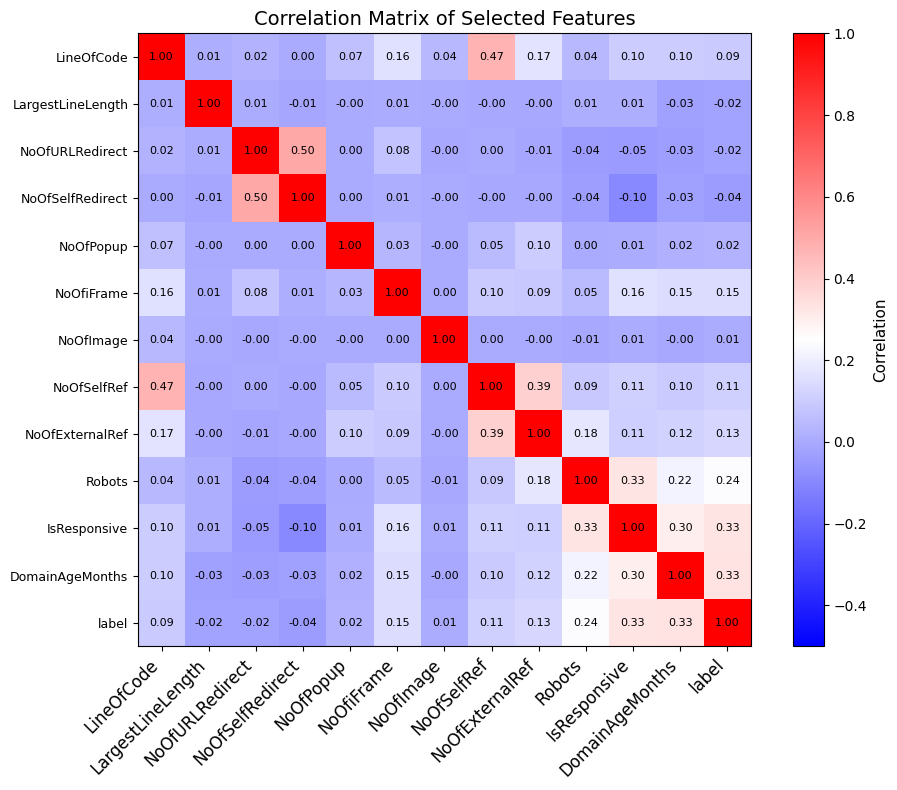

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap="bwr", vmin=-0.5, vmax=1)
ax.set_title("Correlation Matrix of Selected Features", fontsize=14)

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=12)
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=9)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center", va="center",
            fontsize=8, color="black"
        )
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation", fontsize=11)

plt.tight_layout()
plt.show()

### **Correlations with Target 'Label'**

> Correlations to the target variable are prioritised to identify structural indicators of legitimacy.
>
>Based on the output of the correlation calculation with `label` as target, `DomainAgeMonths`, `IsResponsive` and `Robots` have positive correlation. Which means websites that are **responsive, older, and contains robots.txt are more likely to be legit**, signalling their relevance for predictive modelling.
> 
> As for `NoOfSelfRedirect `, `NoOfURLRedirect `, `LargestLineLength`, they show signal leaning toward phishing sites.

In [23]:
print("\nRanked correlation with label:\n")
corr_label = corr["label"].sort_values(ascending=False)
corr_label


Ranked correlation with label:



label                1.000000
DomainAgeMonths      0.332916
IsResponsive         0.330008
Robots               0.241532
NoOfiFrame           0.149633
NoOfExternalRef      0.128117
NoOfSelfRef          0.114407
LineOfCode           0.092799
NoOfPopup            0.023348
NoOfImage            0.009203
LargestLineLength   -0.022636
NoOfURLRedirect     -0.024153
NoOfSelfRedirect    -0.037181
Name: label, dtype: float64

### **Correlations: Feature To Feature Relationships**

In [24]:
records = []
for i in corr.columns:
    for j in corr.columns:
        if i != j:
            if corr.loc[i, j] > 0.3:
                records.append([i, j, corr.loc[i, j], "Positive"])
            elif corr.loc[i, j] < -0.1:
                records.append([i, j, corr.loc[i, j], "Negative"])

corr_table = pd.DataFrame(records, columns=["Feature 1", "Feature 2", "Correlation", "Type"])

corr_table["Correlation"] = corr_table["Correlation"].round(4)

# Sort highest first
corr_table = corr_table.sort_values(by="Correlation", ascending=False)

print("\nFeature-to-Feature Correlations Table (Strongest First):\n")
print(corr_table.to_string(index=False))



Feature-to-Feature Correlations Table (Strongest First):

       Feature 1        Feature 2  Correlation     Type
 NoOfURLRedirect NoOfSelfRedirect       0.5026 Positive
NoOfSelfRedirect  NoOfURLRedirect       0.5026 Positive
      LineOfCode      NoOfSelfRef       0.4672 Positive
     NoOfSelfRef       LineOfCode       0.4672 Positive
     NoOfSelfRef  NoOfExternalRef       0.3893 Positive
 NoOfExternalRef      NoOfSelfRef       0.3893 Positive
           label  DomainAgeMonths       0.3329 Positive
 DomainAgeMonths            label       0.3329 Positive
           label     IsResponsive       0.3300 Positive
    IsResponsive            label       0.3300 Positive
    IsResponsive           Robots       0.3278 Positive
          Robots     IsResponsive       0.3278 Positive
NoOfSelfRedirect     IsResponsive      -0.1011 Negative
    IsResponsive NoOfSelfRedirect      -0.1011 Negative


> Notable positive correlations were observed among link-reference and redirection features, including:
> 
> - `NoOfURLRedirect` and `NoOfSelfRedirect` (corr = 0.5026) as expected, since internal redirect behaviors often occur together.
>  
> - `LineOfCode` and `NoOfSelfRef` (corr = 0.4672) suggesting that pages with dense internal domain linking tend to have larger code footprints, reflecting more complex page structure.
>  
> - `NoOfSelfRef` and `NoOfExternalRef` (corr = 0.3893) indicates that websites that have lots of internal links also usually have lots of external links
> 
> It is observed that redirect-based and reference-link features on the website often co-occur.
>
> Although no feature pairs is at multicollinearity risk, feature coupling groups (Redirects, References) will be re-evaluated later in preprocessing for potential composite feature engineering



## **Summary**

### **Overview**

> Exploratory analysis was conducted on 10,500 web-page records to understand structural and behavioral signals relevant to website legitimacy classification. The dataset is substantial in size and contains a mix of numeric, categorical, and binary indicators that align well with common supervised learning algorithms.
>

### **Class Distribution**
> A slight majority of samples represent legitimate websites(~55%), indicating mild class imbalance but not severe enough to require resampling.
> 
>The classification target label is binary, where:
> - 0 = phishing website
> - 1 = legitimate website
>
### **Data Quality Observations**
> `LineOfCode` was incorrectly stored as a float type and will be converted to integer to reflect its true discrete nature.
> 
> Missing values were detected in `LineOfCode` (22.4%), and notably, all missing entries correspond to phishinglabeled samples, indi cating non-random missing behavior. This suggests the absence of this feature may itself carry predictive signal.
> 
> `NoOfImage` contains negative values (3.59%), which is not logically valid for a count feature. This is attributed to data collection contamination, and will require correction or imputation.
>
> Extreme outliers were detected in the following numeric columns:
> - `LineOfCode`
> - `LargestLineLength`
> - `NoOfPopup`
> - `NoOfiFrame`
> - `NoOfImage`
> - `NoOfSelfRef`
> - `NoOfExternalRef`
>   
>These outliers are technically extreme but contextually plausible, as both phishing and legitimate sites can contain large values, with legitimate sites showing higher magnitudes more frequently.
>
> Categorical inconsistencies were found in the `Industry` column ("ecommerce" and "ecommerce "), which will be unified.
> 
### **Correlation Pattern**
> Correlation evaluation revealed moderate positive relationships in redirect and reference-based features (`NoOfURLRedirect`, `NoOfSelfRedirect`, `NoOfSelfRef`, `NoOfExternalRef`) reflecting valid page behavior, not multicollinearity concerns.
>The most linearly predictive legitimacy signals observed originate from:
> - `IsResponsive`
> - `DomainAgeMonths`
> - `Robots`
> These features show stronger alignment with class separation and will be prioritized for model training.

> **Aside from missing data, negative values, this dataset contains extreme but contextually valid technical distributions**

## **Model Considerations**
> Based on the analysis of the dataset, the following supervised classification algorithmns were selected:
> 
> - **Logistic Regression**: Simple and interpretable linear classifier that performs well when relationships between features and the label have some linear signal. Since correlation analysis showed moderate linear relationship between features. Scaling and optinal clipping will need to be applied since logistic regression is sensitive to scale. 
> 
> - **Random Forest**: Robust tree-based ensemble that handles non-linear behaviour well, prevent overfitting. Suitable for data with many features, extreme values, datamixed data types and missing values.
> 
> - **XGBoost**: Offers stronger learning ability than Random Forest by using gradient optimisation, improving performance on complex data. Suitable for medium size data and lower risk of overfitting. 
> 
> - **CatBoost**: Gradient boosting model specialized for categorical feature handling. No encoding needed so it reduces the risk of category encoding errors. Better stability for categorical groups and strong built-in handling of anomalies.
>


## **Cleaning & Preprocessing for ML Pipeline**
### General Cleaning

>The following cleaning steps will be applied globally to ensure ML compatibility:
>
> - Drop index column `Unnamed: 0`
>   
> - Add Missing flag column for `Null` values in `LineOfCode` to preserve signal.
>
> - Impute median into the missing values in `LineOfCode` to represent typical value, prevent introducing fake patterns.
>
> - Type correction in `LineofCode` (`Float` to `Int`).
>   
> - Unifying categorical labels in `Industry` ("Ecommerce" and "Ecommerce ").
>
> - `NoofImage` negative values will be clipped to 0.
>

### Preprocessing for Logistic Regression
>Feature scaling is applied only when training logistic regression to ensure numerical stability, gradient efficiency, and equal magnitude influence for the linear model. Tree-based models (RF, XGBoost, CatBoost) do not require scaling as their decision boundaries are not distance-dependent.
>
>Scaling for extreme numeric ranges using StandardScaler or RobustScaler
>
>May use Percentile clipping for outliers to maintain linear fairness
>
>Encoding for 2 Categorial Columns:
> - `HostingProvider`
> - `Industry`

### Preprocessing for Random Forest
>
> Outliers are retained as contextually valid
>
>  Encoding for 2 Categorial Columns:
> - `HostingProvider`
> - `Industry`

### Preprocessing for XGBoost
>
> Optional clipping for error-induced outliers
>
> Encoding for 2 Categorial Columns:
> - `HostingProvider`
> - `Industry`

### Preprocessing for CatBoost
>
> Optional clipping for error-induced outliers
> 
> Can read categorials directly so no encoding needed

## Model Evaluation Metrics Selections
> **Objective**: To predict if a website is a phishing attack and warn the user before allowing the user to access it.
> To have an extension that warns user, we also have to consider user experience.
> Here are the metrics I chose to prioritise.
>
> - **F1 Score**:  Balanced metric (Precision + Recall) reflecting reliability in threat detection. We dont want to many False alarms that create bad user experience as an extension.
>
> - **ROC-AUC**: Measures overall ability to separate phishing vs legit across all thresholds.
>
> - **Confusion Matrix**: To check the kind of mistake each model make
>
> For metrics like **Recall**, although it is good for threat prevention, if a model has too many false warning, it makes the extension unreliable. That's when the confusion matrix plays the part to see amount of mistake each model make and weigh the impact.

